In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [73]:
df = pd.read_csv(r"C:\Users\USER\Downloads\archive (3)\jamb_exam_results.csv")

so I need to first know what I am dealing with , currently I'm exploring the data to see and check how it is but also what i need to keep. The first thing i am going to be doing is to clean the data.

In [74]:
df.head(-5)


,JAMB_Score,Study_Hours_Per_Week,Attendance_Rate,Teacher_Quality,Distance_To_School,School_Type,School_Location,Extra_Tutorials,Access_To_Learning_Materials,Parent_Involvement,IT_Knowledge,Student_ID,Age,Gender,Socioeconomic_Status,Parent_Education_Level,Assignments_Completed
0,192,22,78,4,12.4,Public,Urban,Yes,Yes,High,Medium,1,17,Male,Low,Tertiary,2
1,207,14,88,4,2.7,Public,Rural,No,Yes,High,High,2,15,Male,High,NaN,1
2,182,29,87,2,9.6,Public,Rural,Yes,Yes,High,Medium,3,20,Female,High,Tertiary,2
3,210,29,99,2,2.6,Public,Urban,No,Yes,Medium,High,4,22,Female,Medium,Tertiary,1
4,199,12,98,3,8.8,Public,Urban,No,Yes,Medium,Medium,5,22,Female,Medium,Tertiary,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4990,234,25,74,2,3.4,Public,Rural,No,No,High,High,4991,21,Male,Low,Secondary,1
4991,136,19,85,2,15.6,Public,Rural,No,Yes,Medium,High,4992,18,Female,Medium,Primary,2
4992,189,17,87,4,13.2,Private,Rural,Yes,Yes,Low,High,4993,22,Male,Low,NaN,2
4993,200,17,89,3,5.8,Private,Urban,No,Yes,High,Low,4994,18,Male,Low,NaN,1


In [75]:

df.columns

Index(['JAMB_Score', 'Study_Hours_Per_Week', 'Attendance_Rate',
       'Teacher_Quality', 'Distance_To_School', 'School_Type',
       'School_Location', 'Extra_Tutorials', 'Access_To_Learning_Materials',
       'Parent_Involvement', 'IT_Knowledge', 'Student_ID', 'Age', 'Gender',
       'Socioeconomic_Status', 'Parent_Education_Level',
       'Assignments_Completed'],
      dtype='str')

In [76]:
df.shape

(5000, 17)

this gives us a whole view of our data which will help us decide in what we need use. so we start planing on what we are going to keep. and what to clean 

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   JAMB_Score                    5000 non-null   int64  
 1   Study_Hours_Per_Week          5000 non-null   int64  
 2   Attendance_Rate               5000 non-null   int64  
 3   Teacher_Quality               5000 non-null   int64  
 4   Distance_To_School            5000 non-null   float64
 5   School_Type                   5000 non-null   str    
 6   School_Location               5000 non-null   str    
 7   Extra_Tutorials               5000 non-null   str    
 8   Access_To_Learning_Materials  5000 non-null   str    
 9   Parent_Involvement            5000 non-null   str    
 10  IT_Knowledge                  5000 non-null   str    
 11  Student_ID                    5000 non-null   int64  
 12  Age                           5000 non-null   int64  
 13  Gender        

In [78]:
df.nunique()

JAMB_Score                       220
Study_Hours_Per_Week              41
Attendance_Rate                   51
Teacher_Quality                    5
Distance_To_School               201
School_Type                        2
School_Location                    2
Extra_Tutorials                    2
Access_To_Learning_Materials       2
Parent_Involvement                 3
IT_Knowledge                       3
Student_ID                      5000
Age                                8
Gender                             2
Socioeconomic_Status               3
Parent_Education_Level             3
Assignments_Completed              5
dtype: int64

In [79]:
df['JAMB_Score'].unique()


array([192, 207, 182, 210, 199, 202, 251, 129, 220, 157, 188, 158, 191,
       114, 146, 154, 102, 106, 238, 274, 108, 159, 263, 149, 101, 153,
       267, 133, 147, 177, 239, 181, 123, 140, 144, 206, 100, 223, 266,
       134, 104, 172, 222, 136, 185, 164, 113, 189, 262, 231, 151, 103,
       122, 135, 170, 141, 156, 227, 143, 161, 226, 176, 169, 196, 243,
       138, 155, 298, 236, 201, 131, 116, 197, 110, 115, 228, 225, 118,
       232, 215, 200, 211, 218, 171, 183, 245, 160, 119, 107, 221, 150,
       126, 120, 127, 247, 234, 105, 145, 198, 162, 166, 224, 132, 283,
       121, 241, 204, 229, 268, 111, 244, 163, 246, 295, 168, 184, 179,
       190, 142, 212, 299, 180, 249, 128, 208, 195, 112, 216, 194, 152,
       117, 139, 165, 130, 173, 277, 240, 124, 137, 281, 235, 219, 282,
       148, 125, 250, 255, 280, 193, 174, 237, 178, 254, 187, 256, 167,
       270, 230, 109, 308, 175, 214, 285, 209, 292, 279, 213, 186, 261,
       259, 291, 278, 293, 264, 275, 252, 253, 217, 301, 233, 26

In [80]:
df['Student_ID'].unique

<bound method Series.unique of 0          1
1          2
2          3
3          4
4          5
        ... 
4995    4996
4996    4997
4997    4998
4998    4999
4999    5000
Name: Student_ID, Length: 5000, dtype: int64>

In [81]:
df['Parent_Education_Level'].unique

<bound method Series.unique of 0        Tertiary
1             NaN
2        Tertiary
3        Tertiary
4        Tertiary
          ...    
4995      Primary
4996    Secondary
4997      Primary
4998    Secondary
4999          NaN
Name: Parent_Education_Level, Length: 5000, dtype: str>

In [82]:
df.duplicated().sum()

np.int64(0)

In [83]:
df['Age'].nunique

<bound method IndexOpsMixin.nunique of 0       17
1       15
2       20
3       22
4       22
        ..
4995    16
4996    22
4997    18
4998    18
4999    16
Name: Age, Length: 5000, dtype: int64>

I am now going to be making new columns for certain data columns rather than changing because ths will reduce the precision of our dataframe instead we categorize the values and put then into a new column.

In [84]:
def Teacher_Quality_Category(x):
    if x >= 3:
        return "High"
    else:
        return "Low"
    
df["Teacher_Quality_Level"]= df["Teacher_Quality"].apply(Teacher_Quality_Category)
    

In [85]:
def attendance_category(x):
    if x >= 70:
        return "High"
    elif x >= 45:
        return "Moderate"
    else:
        return "Low"
    
df["Attendance_Level"] = df["Attendance_Rate"].apply(attendance_category)

In [86]:
def distance_category(x):
    if x >=15:
        return "Far"
    elif x >= 5:
        return "Moderate"
    else:
        return "Close"
    
df["Distance_Level"]= df["Distance_To_School"].apply(distance_category)

In [109]:
def study_hours_category(x):
    if x > 20:
        return "High"
    elif x >= 10:
        return "Moderate"
    else:
        return "Low"

df["Study_Hours_Level"] = df["Study_Hours_Per_Week"].apply(study_hours_category)

In [110]:
df.columns

Index(['JAMB_Score', 'Study_Hours_Per_Week', 'Attendance_Rate',
       'Teacher_Quality', 'Distance_To_School', 'School_Type',
       'School_Location', 'Extra_Tutorials', 'Access_To_Learning_Materials',
       'Parent_Involvement', 'IT_Knowledge', 'Age', 'Gender',
       'Socioeconomic_Status', 'Assignments_Completed',
       'Teacher_Quality_Level', 'Attendance_Level', 'Distance_Level',
       'Socioeconomic_Number', 'Study_Hours_Level'],
      dtype='str')

so far we want to remove 2 things which are student_ID and parent education levels. Why ? 
 1. For what I plan to do with the data student ID is kind of irrelevant.
 2.  parent education has null data and some information that we cannot use . so it is best to just drop the data 


In [88]:
df.isnull().sum()



JAMB_Score                        0
Study_Hours_Per_Week              0
Attendance_Rate                   0
Teacher_Quality                   0
Distance_To_School                0
School_Type                       0
School_Location                   0
Extra_Tutorials                   0
Access_To_Learning_Materials      0
Parent_Involvement                0
IT_Knowledge                      0
Student_ID                        0
Age                               0
Gender                            0
Socioeconomic_Status              0
Parent_Education_Level          891
Assignments_Completed             0
Teacher_Quality_Level             0
Attendance_Level                  0
Distance_Level                    0
dtype: int64

In [89]:
df.duplicated().sum()

np.int64(0)

In [90]:
df['Parent_Education_Level'].unique

<bound method Series.unique of 0        Tertiary
1             NaN
2        Tertiary
3        Tertiary
4        Tertiary
          ...    
4995      Primary
4996    Secondary
4997      Primary
4998    Secondary
4999          NaN
Name: Parent_Education_Level, Length: 5000, dtype: str>

 ## Updating the data frame 

In [111]:
df.columns


Index(['JAMB_Score', 'Study_Hours_Per_Week', 'Attendance_Rate',
       'Teacher_Quality', 'Distance_To_School', 'School_Type',
       'School_Location', 'Extra_Tutorials', 'Access_To_Learning_Materials',
       'Parent_Involvement', 'IT_Knowledge', 'Age', 'Gender',
       'Socioeconomic_Status', 'Assignments_Completed',
       'Teacher_Quality_Level', 'Attendance_Level', 'Distance_Level',
       'Socioeconomic_Number', 'Study_Hours_Level'],
      dtype='str')

In [112]:
columns_to_keep = [ 'JAMB_Score', 'Study_Hours_Per_Week', 'Attendance_Rate',
       'Teacher_Quality', 'Distance_To_School', 'School_Type',
       'School_Location', 'Extra_Tutorials', 'Access_To_Learning_Materials',
       'Parent_Involvement', 'IT_Knowledge', 'Age', 'Gender',
       'Socioeconomic_Status', 'Assignments_Completed',
       'Teacher_Quality_Level', 'Attendance_Level', 'Distance_Level', 'Study_Hours_Level']

columns_to_remove= ['Student_ID' ,'Parent_Education_Level' ]


In [113]:
print(columns_to_keep)
print(columns_to_remove)

['JAMB_Score', 'Study_Hours_Per_Week', 'Attendance_Rate', 'Teacher_Quality', 'Distance_To_School', 'School_Type', 'School_Location', 'Extra_Tutorials', 'Access_To_Learning_Materials', 'Parent_Involvement', 'IT_Knowledge', 'Age', 'Gender', 'Socioeconomic_Status', 'Assignments_Completed', 'Teacher_Quality_Level', 'Attendance_Level', 'Distance_Level', 'Study_Hours_Level']
['Student_ID', 'Parent_Education_Level']


In [114]:
df = df[columns_to_keep]

the next step is to refine the data make sure that everything is symmetrical and have no duplicates.

In [95]:
df.head(15)

,JAMB_Score,Study_Hours_Per_Week,Attendance_Rate,Teacher_Quality,Distance_To_School,School_Type,School_Location,Extra_Tutorials,Access_To_Learning_Materials,Parent_Involvement,IT_Knowledge,Age,Gender,Socioeconomic_Status,Assignments_Completed,Teacher_Quality_Level,Attendance_Level,Distance_Level
0,192,22,78,4,12.4,Public,Urban,Yes,Yes,High,Medium,17,Male,Low,2,High,High,Moderate
1,207,14,88,4,2.7,Public,Rural,No,Yes,High,High,15,Male,High,1,High,High,Close
2,182,29,87,2,9.6,Public,Rural,Yes,Yes,High,Medium,20,Female,High,2,Low,High,Moderate
3,210,29,99,2,2.6,Public,Urban,No,Yes,Medium,High,22,Female,Medium,1,Low,High,Close
4,199,12,98,3,8.8,Public,Urban,No,Yes,Medium,Medium,22,Female,Medium,1,High,High,Moderate
5,202,25,85,2,13.6,Public,Urban,Yes,No,Medium,Low,15,Male,Low,1,Low,High,Moderate
6,251,35,85,4,2.6,Public,Urban,No,Yes,Low,Medium,16,Female,Medium,4,High,High,Close
7,129,27,75,3,9.4,Public,Urban,No,Yes,Low,Medium,19,Female,Low,3,High,High,Moderate
8,220,23,85,3,4.6,Public,Rural,No,No,Low,Medium,19,Female,Medium,1,High,High,Close
9,157,15,79,3,15.6,Public,Rural,No,Yes,Low,Low,20,Female,Medium,1,High,High,Far


As we can see our data is completely clean and organized. The next step is to start using our data to extract information


The first thing i would like to do is to check the no. of people that passed JAM then followed by making a comparison between the performance of private and public schools

In [143]:
passed = (df["JAMB_Score"] >= 180).sum()
failed = (df["JAMB_Score"] < 180).sum()

print(f"Passed: {passed}")
print(f"Failed: {failed}")

Passed: 2170
Failed: 2830


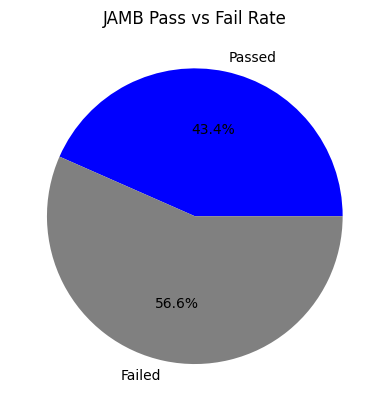

In [144]:
labels = ["Passed", "Failed"]
sizes = [passed, failed]

plt.pie(sizes, labels=labels, colors=["blue", "grey"], autopct="%1.1f%%")

plt.title("JAMB Pass vs Fail Rate")
plt.show()

In [96]:
school_performance = df.groupby("School_Type")["JAMB_Score"].mean()

print(school_performance)

School_Type
Private    181.216601
Public     171.655689
Name: JAMB_Score, dtype: float64


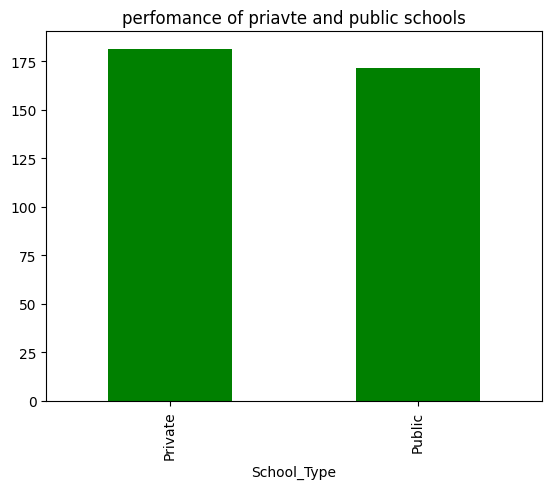

In [97]:

school_performance.plot(kind='bar' , color='Green')
plt.title("perfomance of priavte and public schools")
plt.show()


As we can see the private school perfomance is better than the public school perfomance in general.

the next comparison is going to be based on their access to quality of education.

In [98]:
private_education= df[df['School_Type'] == 'Public']
public_education= df[df['School_Type'] == 'Private']

In [99]:
private_materials = private_education.groupby(["Access_To_Learning_Materials", "Teacher_Quality_Level"])["JAMB_Score"].mean().reset_index()
print(private_materials)

public_materials = public_education.groupby(["Access_To_Learning_Materials", "Teacher_Quality_Level"])["JAMB_Score"].mean().reset_index()
print(public_materials)

  Access_To_Learning_Materials Teacher_Quality_Level  JAMB_Score
0                           No                  High  180.938567
1                           No                   Low  156.775542
2                          Yes                  High  184.456981
3                          Yes                   Low  162.530291
  Access_To_Learning_Materials Teacher_Quality_Level  JAMB_Score
0                           No                  High  192.817734
1                           No                   Low  165.200913
2                          Yes                  High  194.288591
3                          Yes                   Low  169.371212


In [100]:
private_materials["School_Type"] = "Private"

public_materials["School_Type"] = "Public"

comparison = pd.concat([private_materials, public_materials])


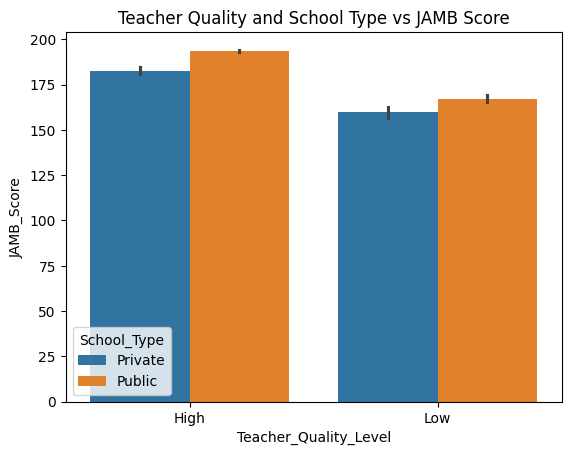

In [101]:
sns.barplot(
    data=comparison,
    x="Teacher_Quality_Level",
    y="JAMB_Score",
    hue="School_Type"
)

plt.title("Teacher Quality and School Type vs JAMB Score")
plt.show()

When it comes to having a better output from their educational foundation, Public schools are better.

We would like to see how many parents take their kids to private or public schools based on their financial income.

In [102]:
socioeconomic_school = df.groupby(
    ["Socioeconomic_Status", "School_Type"]
).size().reset_index(name="Student_Count")

print(socioeconomic_school)

  Socioeconomic_Status School_Type  Student_Count
0                 High     Private            289
1                 High      Public            793
2                  Low     Private            507
3                  Low      Public           1444
4               Medium     Private            469
5               Medium      Public           1498


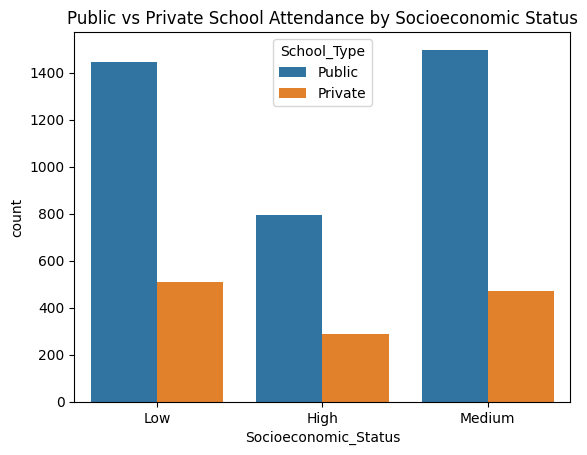

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x="Socioeconomic_Status",
    hue="School_Type"
)

plt.title(
    "Public vs Private School Attendance by Socioeconomic Status"
)

plt.show()

In [104]:
df["Socioeconomic_Number"] = df["Socioeconomic_Status"].map({
    "Low": 1,
    "Medium": 2,
    "High": 3
})

In [105]:
corr_data = df[
    ["JAMB_Score",
     "Distance_To_School",
     "Socioeconomic_Number"]
].copy()

corr_data.columns = [
    "JAMB Score",
    "Distance to School",
    "Socioeconomic Status"
]

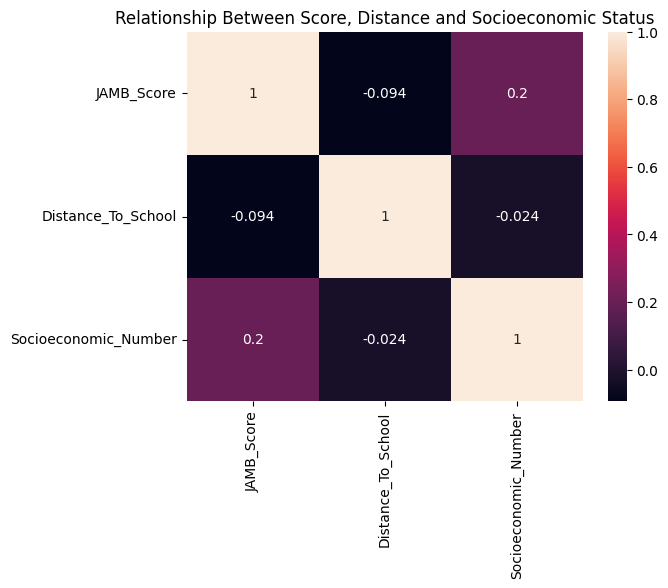

In [106]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(correlation, annot=True)

plt.title("Relationship Between Score, Distance and Socioeconomic Status")

plt.show()

this shows the correlation between the 3 levels of socioeconomic status , distance from school and their jamb scores. as we move up from low to high we can see a btter perfomance on people who live close by and have a higher socioeconomic number tend to perform better. 

In [107]:
distance_ses = df.groupby(
    ["Distance_Level", "Socioeconomic_Status"]
)["JAMB_Score"].mean().reset_index()

print(distance_ses)

  Distance_Level Socioeconomic_Status  JAMB_Score
0          Close                 High  198.021622
1          Close                  Low  172.775000
2          Close               Medium  182.372308
3            Far                 High  183.178947
4            Far                  Low  159.969880
5            Far               Medium  170.078550
6       Moderate                 High  190.874116
7       Moderate                  Low  164.289768
8       Moderate               Medium  173.111365


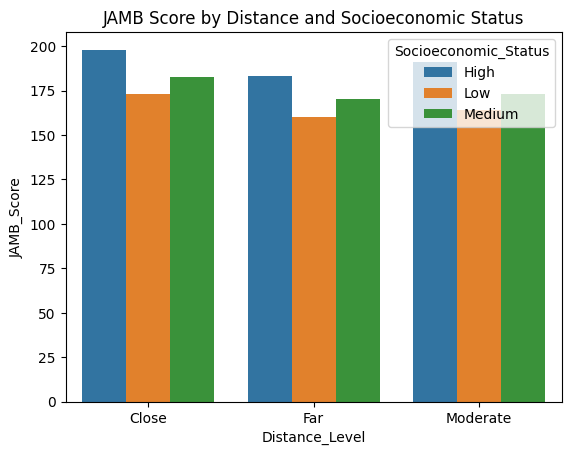

In [108]:
sns.barplot(
    data=distance_ses,
    x="Distance_Level",
    y="JAMB_Score",
    hue="Socioeconomic_Status"
)

plt.title(
    "JAMB Score by Distance and Socioeconomic Status"
)

plt.show()

In [145]:
# find out why the middle class performed the best and their order.

### parents influence involvement on students  JAMB scores

In [118]:
parent_scores = df.groupby("Parent_Involvement")["JAMB_Score"].mean()

print(parent_scores)

Parent_Involvement
High      188.826283
Low       167.253063
Medium    172.292744
Name: JAMB_Score, dtype: float64


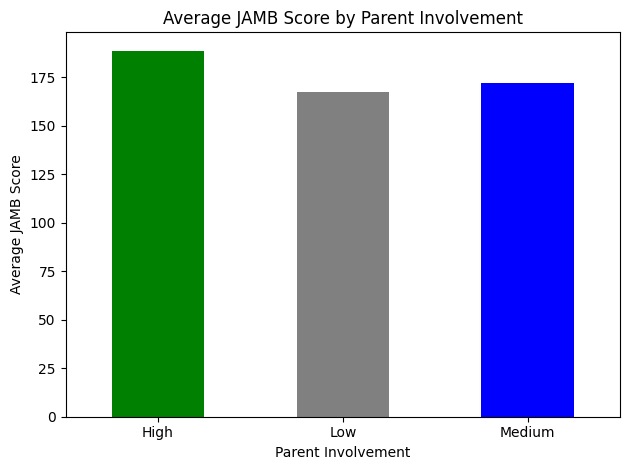

In [140]:


parent_scores = df.groupby("Parent_Involvement")["JAMB_Score"].mean()

parent_scores.plot(kind="bar", color=["green", "gray", "blue"])

plt.title("Average JAMB Score by Parent Involvement")
plt.xlabel("Parent Involvement")
plt.ylabel("Average JAMB Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Studing engaged by students and the output on their performance

In [115]:
study_scores = df.groupby("Study_Hours_Level")["JAMB_Score"].mean()

print(study_scores)

Study_Hours_Level
High        192.184406
Low         146.494297
Moderate    163.917012
Name: JAMB_Score, dtype: float64


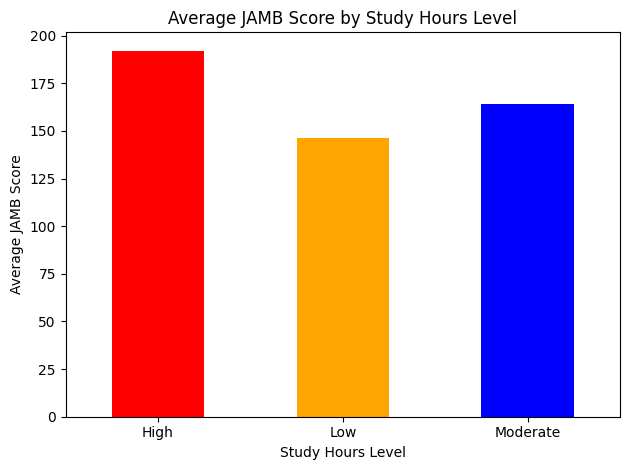

In [141]:


study_scores = df.groupby("Study_Hours_Level")["JAMB_Score"].mean()

study_scores.plot(kind="bar", color=["red", "orange", "blue", "green"])

plt.title("Average JAMB Score by Study Hours Level")
plt.xlabel("Study Hours Level")
plt.ylabel("Average JAMB Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### performance of students with and without extra lessons

In [119]:
tutorial_scores = df.groupby("Extra_Tutorials")["JAMB_Score"].mean()

print(tutorial_scores)

Extra_Tutorials
No     170.566477
Yes    177.012863
Name: JAMB_Score, dtype: float64


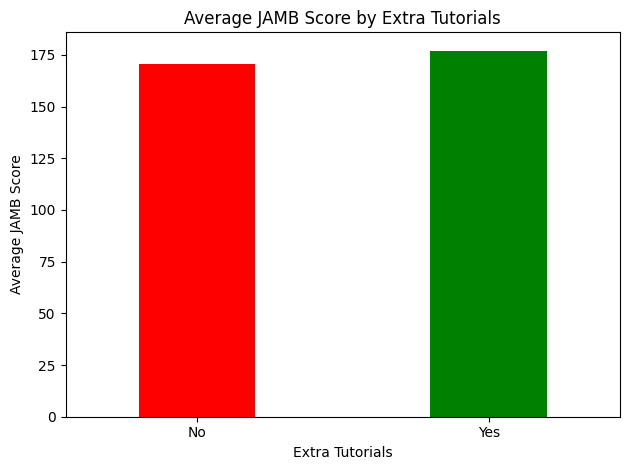

In [142]:
tutorial_scores = df.groupby("Extra_Tutorials")["JAMB_Score"].mean()

tutorial_scores.plot(kind="bar", color=["red", "green"], width=0.4)

plt.title("Average JAMB Score by Extra Tutorials")
plt.xlabel("Extra Tutorials")
plt.ylabel("Average JAMB Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
## find out why or what caused the low performance and how to boost it or the main variable

### Performance on students based on their IT Knowledge

In [139]:
it_scores = df.groupby("IT_Knowledge")["JAMB_Score"].mean() 


print(it_scores)

IT_Knowledge
High      187.303872
Low       166.834962
Medium    172.865990
Name: JAMB_Score, dtype: float64


Text(0, 0.5, 'Average JAMB Score')

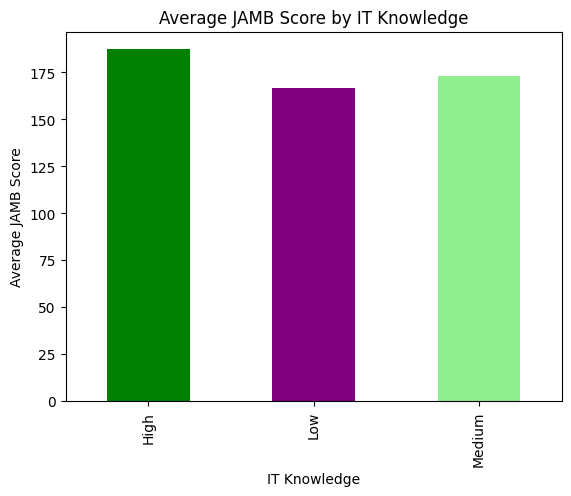

In [138]:
it_scores.plot(
    kind="bar",
    color=["green", "purple", "lightgreen"]
)

plt.title("Average JAMB Score by IT Knowledge")
plt.xlabel("IT Knowledge")
plt.ylabel("Average JAMB Score")


### Performance due to socioeconomic status

In [132]:
school_ses =df.groupby(
    "Socioeconomic_Status"
)["JAMB_Score"].mean()

print(school_ses)

Socioeconomic_Status
High      190.744917
Low       164.772424
Medium    174.131164
Name: JAMB_Score, dtype: float64


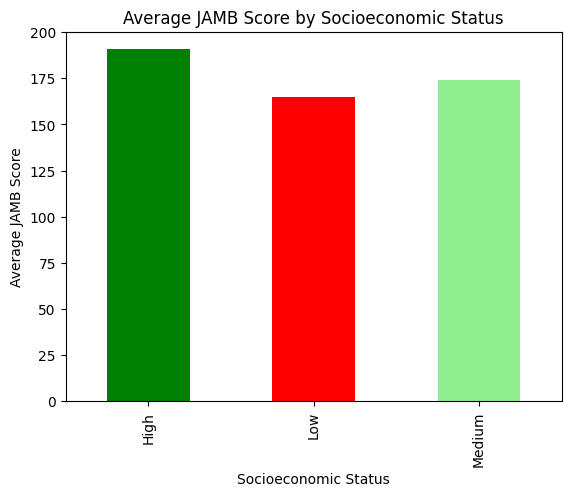

In [134]:
school_ses.plot(
    kind="bar",
    color=["green", "red", "lightgreen"]
)

plt.title("Average JAMB Score by Socioeconomic Status")
plt.xlabel("Socioeconomic Status")
plt.ylabel("Average JAMB Score")

plt.show()

### Number of high performing students from each socioeconomic group

In [124]:

top_students = df[df["JAMB_Score"] >= 250]


top_students["School_Type"].value_counts()

top_students["Extra_Tutorials"].value_counts()

top_students["Socioeconomic_Status"].value_counts()

Socioeconomic_Status
Medium    105
High      104
Low        37
Name: count, dtype: int64

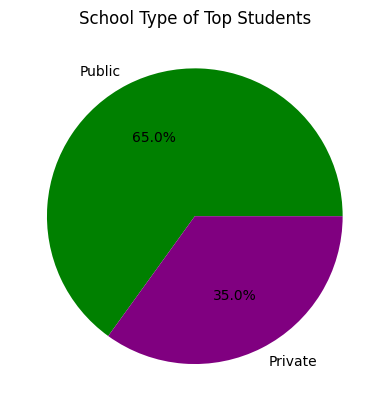

In [130]:
school_counts = top_students["School_Type"].value_counts()

plt.pie(
    school_counts,
    labels=school_counts.index,
    autopct="%1.1f%%",
    colors=["green", "purple"]
)

plt.title("School Type of Top Students")
plt.show()

as we can see people from the medium class achieved greater scores, follow by the high socioeconomic then in last goes to the low socioeconomic level

### This shows the studence performance based on their location, distance to their schools, and school type and a how it affects their performance 

In [149]:
result = df.groupby(["School_Location", "Distance_Level", "School_Type"])["JAMB_Score"].mean().reset_index()
print(result)

   School_Location Distance_Level School_Type  JAMB_Score
0            Rural          Close     Private  176.581395
1            Rural          Close      Public  179.183267
2            Rural            Far     Private  183.200000
3            Rural            Far      Public  168.258303
4            Rural       Moderate     Private  179.586957
5            Rural       Moderate      Public  168.619005
6            Urban          Close     Private  198.356522
7            Urban          Close      Public  181.390533
8            Urban            Far     Private  176.430894
9            Urban            Far      Public  164.008021
10           Urban       Moderate     Private  180.084016
11           Urban       Moderate      Public  173.057307


check out why suprisingly the rural private school students perform better when school is far and the public vice versa and can we say that urban education  is better due to results. ####

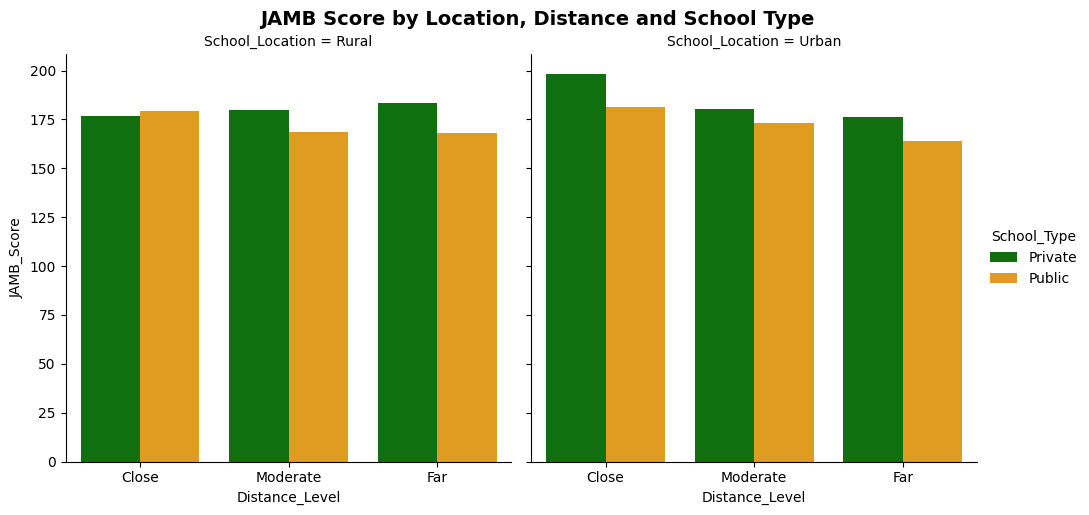

In [148]:
result = df.groupby(["School_Location", "Distance_Level", "School_Type"])["JAMB_Score"].mean().reset_index()

sns.catplot(
    data=result,
    x="Distance_Level",
    y="JAMB_Score",
    hue="School_Type",
    col="School_Location",
    kind="bar",
    palette=["green", "orange"],
    order=["Close", "Moderate", "Far"]
)

plt.suptitle("JAMB Score by Location, Distance and School Type", y=1.02, fontsize=14, fontweight="bold")
plt.show()

### Attendace level and the outcome of their performance 


In [150]:
attendance_school = df.groupby("School_Type")["Attendance_Rate"].mean()
print(attendance_school)


School_Type
Private    85.166008
Public     83.919946
Name: Attendance_Rate, dtype: float64


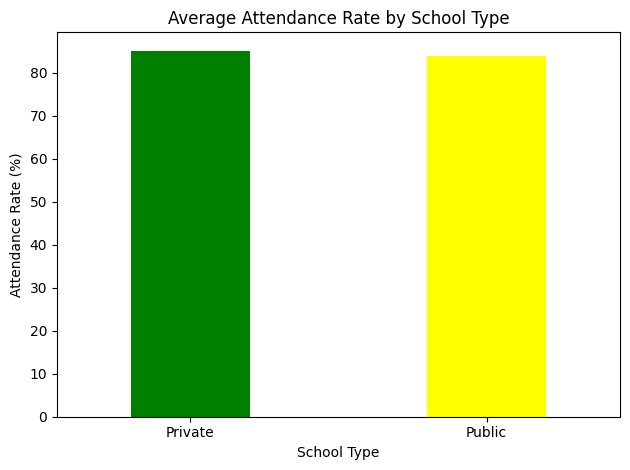

In [154]:
attendance_school = df.groupby("School_Type")["Attendance_Rate"].mean()

attendance_school.plot(kind="bar", color=["green", "yellow"], width=0.4)
plt.title("Average Attendance Rate by School Type")
plt.xlabel("School Type")
plt.ylabel("Attendance Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

private school students have a higher rate of attending school then public school students but this doesnt really tell the full story and the rate is not that significant

In [152]:
attendance_combined = df.groupby(
    ["Attendance_Level", "Distance_Level", "School_Location", "School_Type"]
)["JAMB_Score"].mean().round(1)

print(attendance_combined)

Attendance_Level  Distance_Level  School_Location  School_Type
High              Close           Rural            Private        177.2
                                                   Public         180.7
                                  Urban            Private        200.1
                                                   Public         184.1
                  Far             Rural            Private        187.3
                                                   Public         170.5
                                  Urban            Private        176.9
                                                   Public         164.8
                  Moderate        Rural            Private        181.6
                                                   Public         170.3
                                  Urban            Private        180.7
                                                   Public         174.7
Moderate          Close           Rural            Private        159.0
 

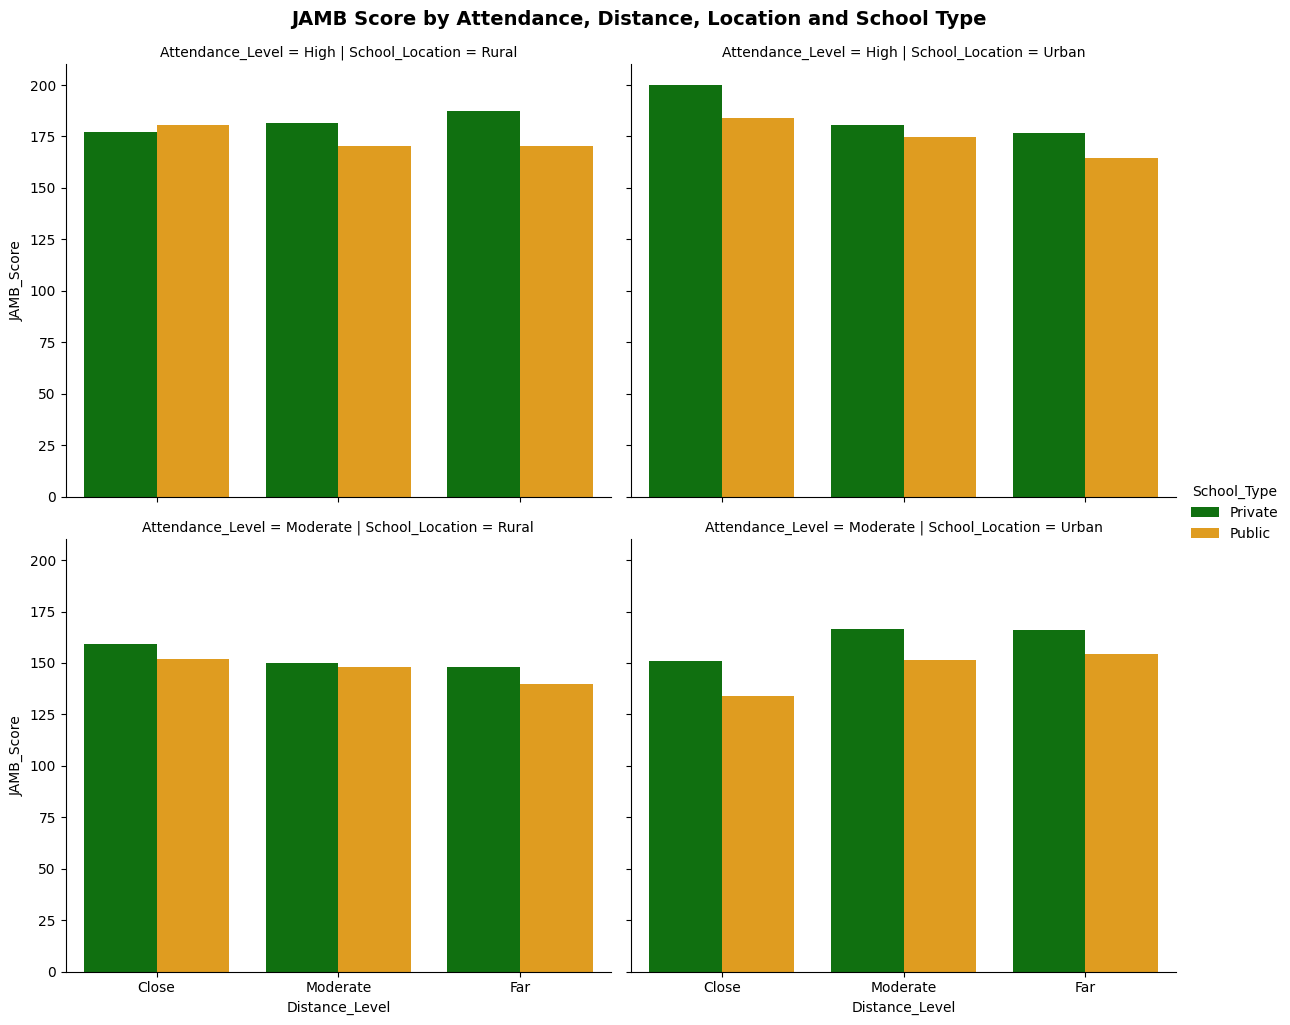

In [157]:
combined = df.groupby(
    ["Attendance_Level", "Distance_Level", "School_Location", "School_Type"]
)["JAMB_Score"].mean().reset_index()

sns.catplot(
    data=combined,
    x="Distance_Level",
    y="JAMB_Score",
    hue="School_Type",
    col="School_Location",
    row="Attendance_Level",
    kind="bar",
    palette=["green", "orange"],
    order=["Close", "Moderate", "Far"],
    aspect=1.2
)

plt.suptitle("JAMB Score by Attendance, Distance, Location and School Type", y=1.02, fontsize=14, fontweight="bold")
plt.show()

We can see through the data that most people who where closer to school and lived in the urban area All passed. The failure rate was high for people that attended class moderately and especially people that lived moderately away from school was the biggest factopr of the failure. suprisingly there were no people that did not attend class.

In [ ]:
#can we do anything to make the moderate student get pass and what can we do to make the rest pass

### How assignments influence students performances

In [158]:
assignments_scores = df.groupby("Assignments_Completed")["JAMB_Score"].mean().round(1)
print(assignments_scores)

Assignments_Completed
1    162.0
2    180.8
3    188.3
4    200.2
5    216.0
Name: JAMB_Score, dtype: float64


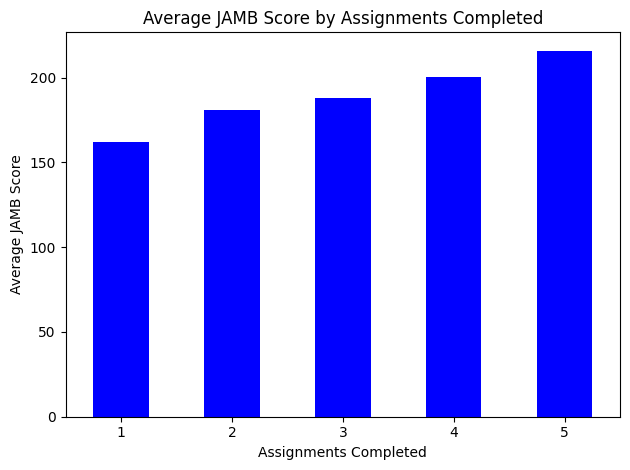

In [159]:
assignments_scores.plot(kind="bar", color="blue", width=0.5)
plt.title("Average JAMB Score by Assignments Completed")
plt.xlabel("Assignments Completed")
plt.ylabel("Average JAMB Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [160]:
result = df.groupby(["Assignments_Completed", "School_Type"])["JAMB_Score"].mean().round(1).unstack()
print(result)


School_Type            Private  Public
Assignments_Completed                 
1                        168.3   160.1
2                        185.9   179.0
3                        197.5   184.6
4                        213.5   196.0
5                        195.9   220.5


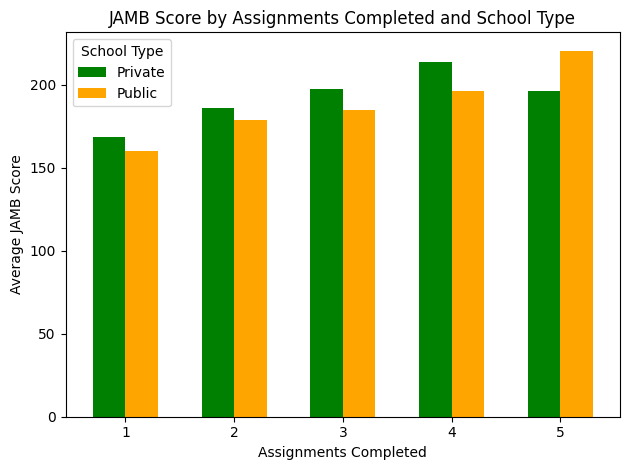

In [161]:
result.plot(kind="bar", color=["green", "orange"], width=0.6)
plt.title("JAMB Score by Assignments Completed and School Type")
plt.xlabel("Assignments Completed")
plt.ylabel("Average JAMB Score")
plt.xticks(rotation=0)
plt.legend(title="School Type")
plt.tight_layout()
plt.show()

over all students have a better performance based on the greater number of assignments they complete. Public school students with level 5 completion of assignments out perform private school students

### Gender influence on the outcome of student results

In [162]:
gender_scores = df.groupby("Gender")["JAMB_Score"].mean().round(1)
print(gender_scores)

Gender
Female    174.8
Male      173.4
Name: JAMB_Score, dtype: float64


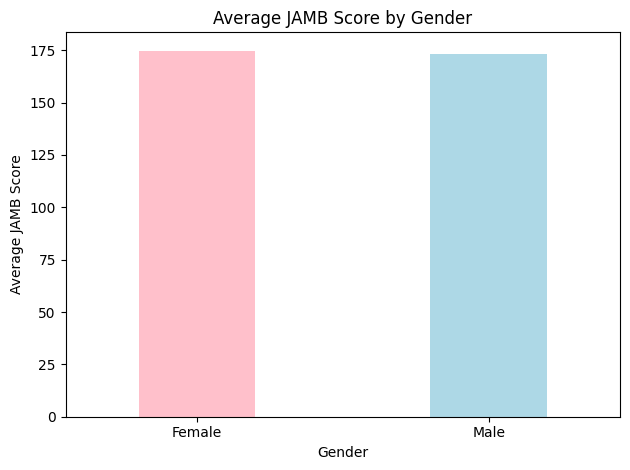

In [164]:
gender_scores.plot(kind="bar", color=["pink", "lightblue"], width=0.4)
plt.title("Average JAMB Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average JAMB Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

when taking gender alone into consideration we can see that, it's not really enough to say it has an influence in the overall performance so definetly we have to combine it with other measures to see an over all better performance. but females do out perform males by a little bit

In [165]:
gender_school = df.groupby(["Gender", "School_Type"])["JAMB_Score"].mean().round(1).unstack()
print(gender_school)

School_Type  Private  Public
Gender                      
Female         181.7   172.3
Male           180.7   171.0


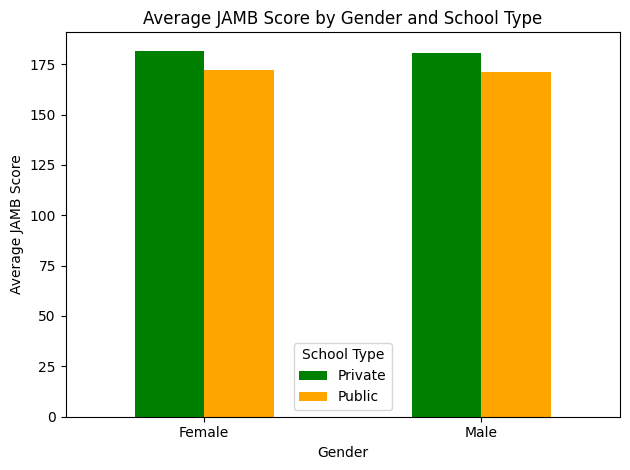

In [166]:
gender_school.plot(kind="bar", color=["green", "orange"], width=0.5)
plt.title("Average JAMB Score by Gender and School Type")
plt.xlabel("Gender")
plt.ylabel("Average JAMB Score")
plt.xticks(rotation=0)
plt.legend(title="School Type")
plt.tight_layout()
plt.show()

As we can see there is not really much of a difference in the comparison of gender but we can notice that the type of school does matter, both genders tend to pass if they have private education. The females performance was better thane the males in both sectors

### Outcome of the students performance based on their age

In [167]:
age_scores = df.groupby("Age")["JAMB_Score"].mean().round(1)
print(age_scores)



Age
15    172.6
16    178.7
17    177.4
18    172.6
19    174.2
20    172.1
21    172.4
22    172.1
Name: JAMB_Score, dtype: float64


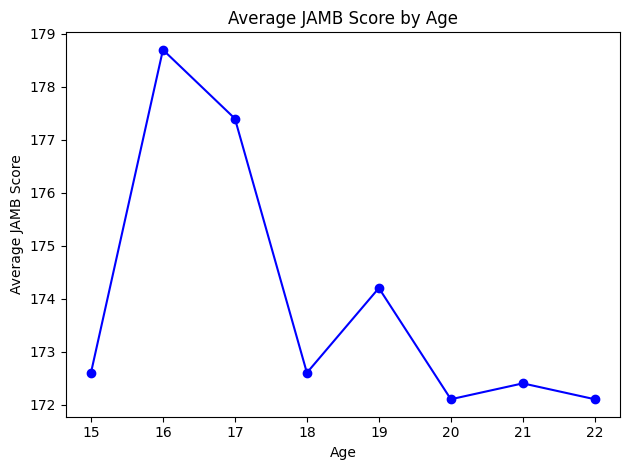

In [168]:
age_scores.plot(kind="line", color="blue", marker="o")
plt.title("Average JAMB Score by Age")
plt.xlabel("Age")
plt.ylabel("Average JAMB Score")
plt.xticks(df["Age"].unique())
plt.tight_layout()
plt.show()

The sweet spot for people that perform better age wise is 16 years old. so we can say performance declines after the age of 16. Still this is not enough to give you an advantage alone so if its mostly paired with other factors then for sure a better chance of higher performance

In [170]:
result = df.groupby(["Age", "School_Type"])["JAMB_Score"].mean().round(1).reset_index()
print(result)

    Age School_Type  JAMB_Score
0    15     Private       184.9
1    15      Public       168.7
2    16     Private       182.2
3    16      Public       177.5
4    17     Private       185.1
5    17      Public       174.8
6    18     Private       179.1
7    18      Public       170.5
8    19     Private       182.4
9    19      Public       171.1
10   20     Private       174.4
11   20      Public       171.3
12   21     Private       185.8
13   21      Public       168.0
14   22     Private       175.1
15   22      Public       171.1


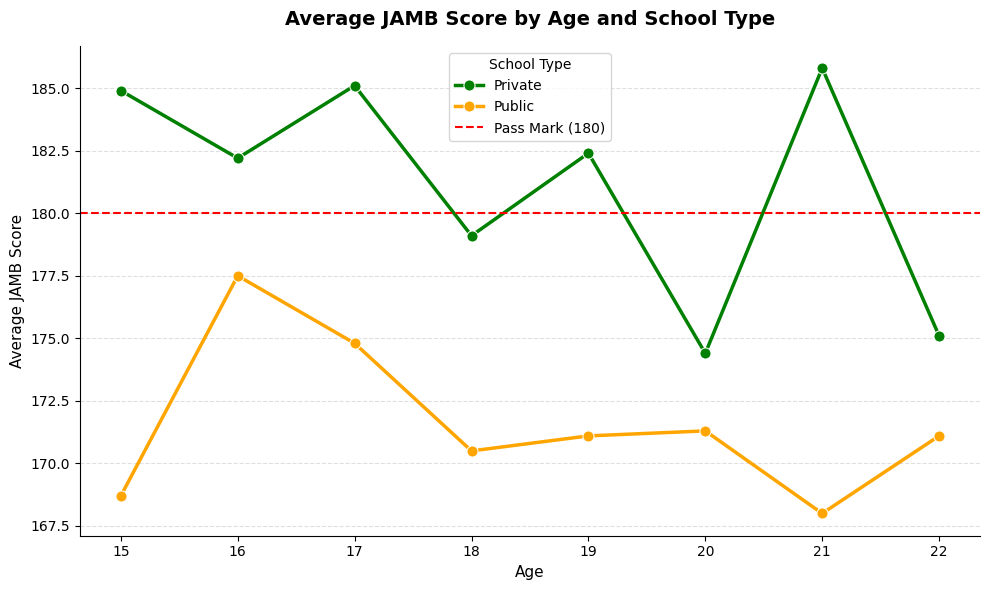

<Figure size 640x480 with 0 Axes>

: 

In [ ]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=result,
    x="Age",
    y="JAMB_Score",
    hue="School_Type",
    palette=["green", "orange"],
    marker="o",
    linewidth=2.5,
    markersize=8
)

plt.axhline(y=180, color="red", linestyle="--", linewidth=1.5, label="Pass Mark (180)")
plt.title("Average JAMB Score by Age and School Type", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Age", fontsize=11)
plt.ylabel("Average JAMB Score", fontsize=11)
plt.xticks(df["Age"].unique())
plt.legend(title="School Type")
plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()
plt.tight_layout()
plt.show()
sns.despine() 

As we can see that when it comes to the combination of age and school type, either way public school students don't pass. For private schools everyone passes but  te 18, 20, and 22 year olds.

In [ ]:
# what causes the these 3 age groups to spefically fail and what can we do for a better performance. 
# and for public school what can we do to make them perform better